In [2]:
import os
os.chdir("C:/Users/ambis/Downloads")

df = pd.read_csv("kfc_orders_2026.csv")

In [6]:
df.shape

(389713, 23)

In [7]:
df.head(5)

,order_id,date,month,quarter,week_number,day_of_week,hour,minute,is_wednesday,is_weekend,...,item_name,category,quantity,unit_price,discount_pct,total_price,order_status,delivery_time_mins,is_late_delivery,customer_id
0,1000000,2026-01-01,1,1,1,Thu,13,7,0,0,...,Hot & Crispy Chicken,Chicken,1,399,0.0,399.0,Completed,35,0,CUST023986
1,1000001,2026-01-01,1,1,1,Thu,20,7,0,0,...,Chicken Strips 3Pcs,Chicken,1,299,0.0,299.0,Completed,37,0,CUST848688
2,1000002,2026-01-01,1,1,1,Thu,15,36,0,0,...,Popcorn Chicken,Chicken,3,199,0.0,597.0,Completed,34,0,CUST633094
3,1000003,2026-01-01,1,1,1,Thu,14,50,0,0,...,Veg Rice Bowl,Sides,1,179,0.0,179.0,Completed,36,0,CUST782838
4,1000004,2026-01-01,1,1,1,Thu,19,35,0,0,...,Zinger Burger,Burgers,1,249,0.0,249.0,Completed,0,0,CUST871882


In [8]:
df.tail(5)

,order_id,date,month,quarter,week_number,day_of_week,hour,minute,is_wednesday,is_weekend,...,item_name,category,quantity,unit_price,discount_pct,total_price,order_status,delivery_time_mins,is_late_delivery,customer_id
389708,1389708,2026-04-30,4,2,18,Thu,12,33,0,0,...,Corn on the Cob,Sides,2,99,0.0,198.0,Completed,34,0,CUST529757
389709,1389709,2026-04-30,4,2,18,Thu,21,2,0,0,...,Mashed Potato,Sides,1,89,0.0,89.0,Completed,25,0,CUST228422
389710,1389710,2026-04-30,4,2,18,Thu,11,12,0,0,...,Veg Rice Bowl,Sides,1,179,0.0,179.0,Completed,35,0,CUST362725
389711,1389711,2026-04-30,4,2,18,Thu,20,20,0,0,...,Veg Rice Bowl,Sides,2,179,0.0,358.0,Completed,29,0,CUST032485
389712,1389712,2026-04-30,4,2,18,Thu,19,49,0,0,...,Zinger Burger,Burgers,3,249,0.0,747.0,Completed,32,0,CUST837006


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 389713 entries, 0 to 389712
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            389713 non-null  int64  
 1   date                389713 non-null  str    
 2   month               389713 non-null  int64  
 3   quarter             389713 non-null  int64  
 4   week_number         389713 non-null  int64  
 5   day_of_week         389713 non-null  str    
 6   hour                389713 non-null  int64  
 7   minute              389713 non-null  int64  
 8   is_wednesday        389713 non-null  int64  
 9   is_weekend          389713 non-null  int64  
 10  city                389713 non-null  str    
 11  outlet_id           389713 non-null  str    
 12  channel             389713 non-null  str    
 13  item_name           389713 non-null  str    
 14  category            389713 non-null  str    
 15  quantity            389713 non-null  int64  


In [17]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

order_id              0
date                  0
month                 0
quarter               0
week_number           0
day_of_week           0
hour                  0
minute                0
is_wednesday          0
is_weekend            0
city                  0
outlet_id             0
channel               0
item_name             0
category              0
quantity              0
unit_price            0
discount_pct          0
total_price           0
order_status          0
delivery_time_mins    0
is_late_delivery      0
customer_id           0
dtype: int64

In [10]:
df.describe

<bound method NDFrame.describe of         order_id        date  month  quarter  week_number day_of_week  hour  \
0        1000000  2026-01-01      1        1            1         Thu    13   
1        1000001  2026-01-01      1        1            1         Thu    20   
2        1000002  2026-01-01      1        1            1         Thu    15   
3        1000003  2026-01-01      1        1            1         Thu    14   
4        1000004  2026-01-01      1        1            1         Thu    19   
...          ...         ...    ...      ...          ...         ...   ...   
389708   1389708  2026-04-30      4        2           18         Thu    12   
389709   1389709  2026-04-30      4        2           18         Thu    21   
389710   1389710  2026-04-30      4        2           18         Thu    11   
389711   1389711  2026-04-30      4        2           18         Thu    20   
389712   1389712  2026-04-30      4        2           18         Thu    19   

        minute  i

In [3]:
total_sales = df['total_price'].sum()
total_orders = df['order_id'].count()
total_customers = df['customer_id'].nunique()

In [16]:
df['date'] = pd.to_datetime(df['date'])

monthly_sales = df.groupby(df['date'].dt.to_period('M'))['total_price'].sum()
monthly_sales

date
2026-01    50747258.6
2026-02    46791693.8
2026-03    52175037.8
2026-04    52081169.8
Freq: M, Name: total_price, dtype: float64

In [15]:
peak_hours = df.groupby('hour')['order_id'].count().sort_values(ascending=False)
peak_hours

hour
19    35060
12    35017
20    33276
18    31294
13    31191
21    27247
11    25321
17    23410
14    21467
16    19550
15    17415
10    17376
9     15582
22    15508
8     13757
7      9703
23     5915
6      3892
5      1955
0      1944
1      1163
4      1118
3       797
2       755
Name: order_id, dtype: int64

In [18]:
city_sales = df.groupby('city')['total_price'].sum().sort_values(ascending=False)
city_sales

city
Delhi        36238924.8
Mumbai       34177596.6
Bengaluru    30092725.0
Hyderabad    24234455.2
Chennai      20150105.0
Pune         18254290.4
Kolkata      14198645.4
Ahmedabad    12136552.4
Jaipur        8211998.2
Lucknow       4099867.0
Name: total_price, dtype: float64

In [19]:
top_products = df.groupby('item_name')['total_price'].sum().sort_values(ascending=False).head(5)
top_products 

item_name
Chicken Bucket 8Pcs     53248981.2
Hot & Crispy Chicken    49268759.4
Zinger Burger           27068242.2
Chicken Strips 3Pcs     26706440.8
Popcorn Chicken         14265315.0
Name: total_price, dtype: float64

In [20]:
low_products = df.groupby('item_name')['total_price'].sum().sort_values().head(5)
low_products

item_name
Iced Tea           533408.0
Brownie Sundae     887365.2
Coleslaw          1081826.0
Pepsi Can         2026788.0
Mashed Potato     2415816.0
Name: total_price, dtype: float64

In [21]:
late_pct = (df['is_late_delivery'].sum() / len(df)) * 100
late_pct

np.float64(0.7836536117604493)

In [22]:
weekend_sales = df.groupby('is_weekend')['total_price'].sum()
weekend_sales

is_weekend
0    140913382.0
1     60881778.0
Name: total_price, dtype: float64

In [23]:
avg_delivery = df['delivery_time_mins'].mean()
avg_delivery

np.float64(25.205405003169)

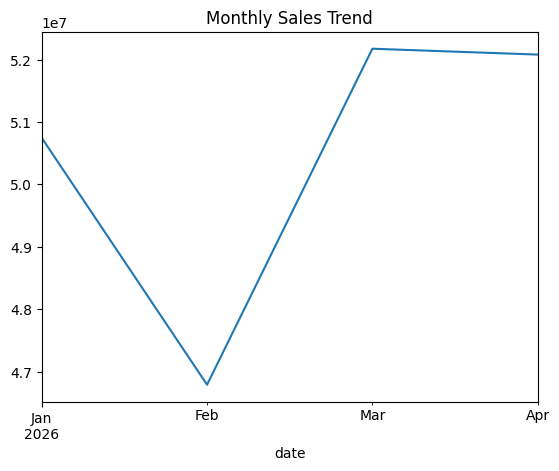

In [24]:
import matplotlib.pyplot as plt

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()